# 🫀 Oura Ring — Analyse de corrélations : Âge cardiovasculaire

Ce notebook charge les données depuis Snowflake, construit une table maître journalière
et explore les corrélations statistiques entre les métriques de santé et l'âge cardiovasculaire.

**Plan :**
1. Setup & Connexion
2. Chargement des données
3. Analyse exploratoire (EDA)
4. Matrice de corrélation (Pearson & Spearman)
5. Scatter plots — top corrélateurs
6. Analyse par moyennes glissantes (7j / 14j)
7. Analyse des décalages temporels (lag)
8. Séries temporelles
9. Interprétation via l'API Claude *(optionnel)*

---
## 1 · Setup & Connexion

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
import snowflake.connector

warnings.filterwarnings('ignore')
load_dotenv(dotenv_path=Path('..') / '.env')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Libraries loaded')

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded


/Users/renaudbeufils/Library/Python/3.9/lib/python/site-packages/snowflake/connector/vendored/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
DB     = os.environ['SF_DATABASE']
SCHEMA = os.environ.get('SF_SCHEMA', 'OURA')

kw = dict(
    account   = os.environ['SF_ACCOUNT'],
    user      = os.environ['SF_USER'],
    password  = os.environ['SF_PASSWORD'],
    warehouse = os.environ['SF_WAREHOUSE'],
    database  = DB,
    schema    = SCHEMA,
)
if os.environ.get('SF_ROLE'):
    kw['role'] = os.environ['SF_ROLE']

conn = snowflake.connector.connect(**kw)
print(f'✅ Connecté à Snowflake — {DB}.{SCHEMA}')

✅ Connecté à Snowflake — OURA.public


---
## 2 · Chargement des données

La requête joint toutes les tables sur la colonne `DAY` (clé de la table `CALENDAR`).
Les durées Oura (en secondes) sont converties en **minutes** pour la lisibilité.
`VO2_MAX` est propagé vers l'avant (*forward-fill*) car la mesure est peu fréquente.

In [ ]:
SQL = f'''
SELECT
    c.DAY,
    c.WEEKDAY,
    -- Âge cardiovasculaire (variable cible)
    cv.VASCULAR_AGE,
    -- Activité
    act.SCORE               AS ACTIVITY_SCORE,
    act.STEPS,
    act.ACTIVE_CALORIES,
    act.TOTAL_CALORIES,
    act.HIGH_ACTIVITY_TIME,
    act.MEDIUM_ACTIVITY_TIME,
    act.SEDENTARY_TIME,
    act.TRAINING_FREQUENCY,
    act.TRAINING_VOLUME,
    act.AVERAGE_MET_MINUTES,
    -- Forme / Readiness
    rdy.SCORE               AS READINESS_SCORE,
    rdy.HRV_BALANCE,
    rdy.RECOVERY_INDEX,
    rdy.RESTING_HEART_RATE  AS READINESS_RHR,
    rdy.TEMPERATURE_DEVIATION,
    rdy.ACTIVITY_BALANCE,
    rdy.SLEEP_BALANCE,
    -- Sommeil (scores contributeurs)
    sl.SCORE                AS SLEEP_SCORE,
    sl.DEEP_SLEEP,
    sl.REM_SLEEP,
    sl.EFFICIENCY           AS SLEEP_EFFICIENCY,
    sl.TOTAL_SLEEP,
    sl.RESTFULNESS,
    sl.TIMING               AS SLEEP_TIMING,
    -- Sessions de sommeil (durées brutes)
    ss.TOTAL_SLEEP_DURATION,
    ss.DEEP_SLEEP_DURATION,
    ss.REM_SLEEP_DURATION,
    ss.AVERAGE_HRV,
    ss.LOWEST_HEART_RATE,
    -- Stress
    st.STRESS_HIGH,
    st.RECOVERY_HIGH,
    -- SpO2
    spo.SPO2_AVERAGE,
    -- VO2 Max
    vo.VO2_MAX
FROM {DB}.{SCHEMA}.CALENDAR c
LEFT JOIN {DB}.{SCHEMA}.DAILY_CARDIOVASCULAR_AGE cv  ON cv.DAY  = c.DAY
LEFT JOIN {DB}.{SCHEMA}.DAILY_ACTIVITY          act  ON act.DAY = c.DAY
LEFT JOIN {DB}.{SCHEMA}.DAILY_READINESS         rdy  ON rdy.DAY = c.DAY
LEFT JOIN {DB}.{SCHEMA}.DAILY_SLEEP             sl   ON sl.DAY  = c.DAY
LEFT JOIN (
    SELECT DAY,
           SUM(TOTAL_SLEEP_DURATION) AS TOTAL_SLEEP_DURATION,
           SUM(DEEP_SLEEP_DURATION)  AS DEEP_SLEEP_DURATION,
           SUM(REM_SLEEP_DURATION)   AS REM_SLEEP_DURATION,
           AVG(AVERAGE_HRV)          AS AVERAGE_HRV,
           MIN(LOWEST_HEART_RATE)    AS LOWEST_HEART_RATE
    FROM {DB}.{SCHEMA}.SLEEP_SESSIONS
    WHERE TYPE = $$long_sleep$$
    GROUP BY DAY
) ss ON ss.DAY = c.DAY
LEFT JOIN {DB}.{SCHEMA}.DAILY_STRESS st  ON st.DAY  = c.DAY
LEFT JOIN {DB}.{SCHEMA}.DAILY_SPO2   spo ON spo.DAY = c.DAY
LEFT JOIN {DB}.{SCHEMA}.VO2_MAX      vo  ON vo.DAY  = c.DAY
WHERE c.DAY >= $$2020-01-01$$ AND c.DAY <= CURRENT_DATE()
ORDER BY c.DAY
'''

# Snowflake accepte $$ comme délimiteur de chaîne → pas de conflit avec les quotes Python
SQL = SQL.replace('$$', "'")

cur = conn.cursor()
cur.execute(SQL)
df_raw = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
df_raw['DAY'] = pd.to_datetime(df_raw['DAY'])
df_raw = df_raw.set_index('DAY').sort_index()

# VO2_MAX : forward-fill (mesure peu fréquente)
df_raw['VO2_MAX'] = df_raw['VO2_MAX'].ffill()

# Secondes → minutes
SEC_COLS = [
    'TOTAL_SLEEP_DURATION', 'DEEP_SLEEP_DURATION', 'REM_SLEEP_DURATION',
    'HIGH_ACTIVITY_TIME',   'MEDIUM_ACTIVITY_TIME', 'SEDENTARY_TIME',
    'STRESS_HIGH',          'RECOVERY_HIGH',
]
for col in SEC_COLS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col] / 60

df = df_raw.rename(columns={
    'TOTAL_SLEEP_DURATION': 'SLEEP_DURATION_MIN',
    'DEEP_SLEEP_DURATION':  'DEEP_SLEEP_MIN',
    'REM_SLEEP_DURATION':   'REM_SLEEP_MIN',
    'HIGH_ACTIVITY_TIME':   'HIGH_ACTIVITY_MIN',
    'MEDIUM_ACTIVITY_TIME': 'MEDIUM_ACTIVITY_MIN',
    'SEDENTARY_TIME':       'SEDENTARY_MIN',
    'STRESS_HIGH':          'STRESS_HIGH_MIN',
    'RECOVERY_HIGH':        'RECOVERY_HIGH_MIN',
})

# Cast float64 — Snowflake retourne decimal.Decimal pour les colonnes NUMBER,
# incompatible avec scipy (pearsonr, spearmanr). errors='coerce' laisse
# les colonnes non-numériques (index DAY) intactes.
df = df.apply(pd.to_numeric, errors='coerce')

n_cv = df['VASCULAR_AGE'].notna().sum()
print(f'✅ {len(df)} jours chargés  ({df.index.min().date()} → {df.index.max().date()})')
print(f'   VASCULAR_AGE disponible : {n_cv} jours sur {len(df)}')

---
## 3 · Analyse exploratoire (EDA)

In [4]:
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n')
print('── Statistiques VASCULAR_AGE ──')
print(df['VASCULAR_AGE'].describe().round(2))

Dimensions : 2448 lignes × 35 colonnes

── Statistiques VASCULAR_AGE ──
count    875.00
mean      40.37
std        2.31
min       33.00
25%       39.00
50%       41.00
75%       42.00
max       47.00
Name: VASCULAR_AGE, dtype: float64


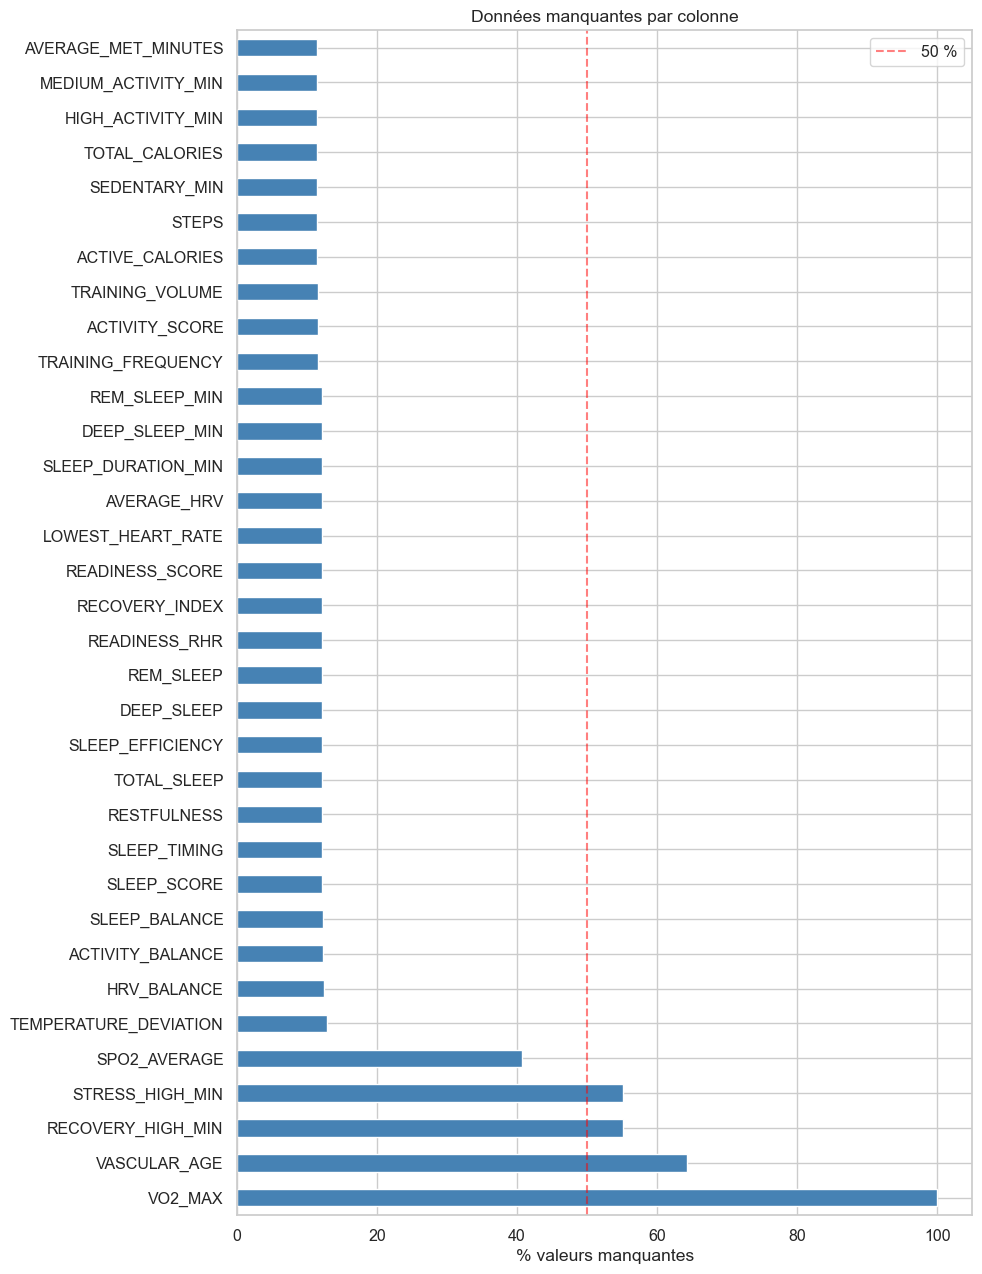

In [5]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.38)))
missing.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50 %')
ax.set_xlabel('% valeurs manquantes')
ax.set_title('Données manquantes par colonne')
ax.legend()
plt.tight_layout()
plt.show()

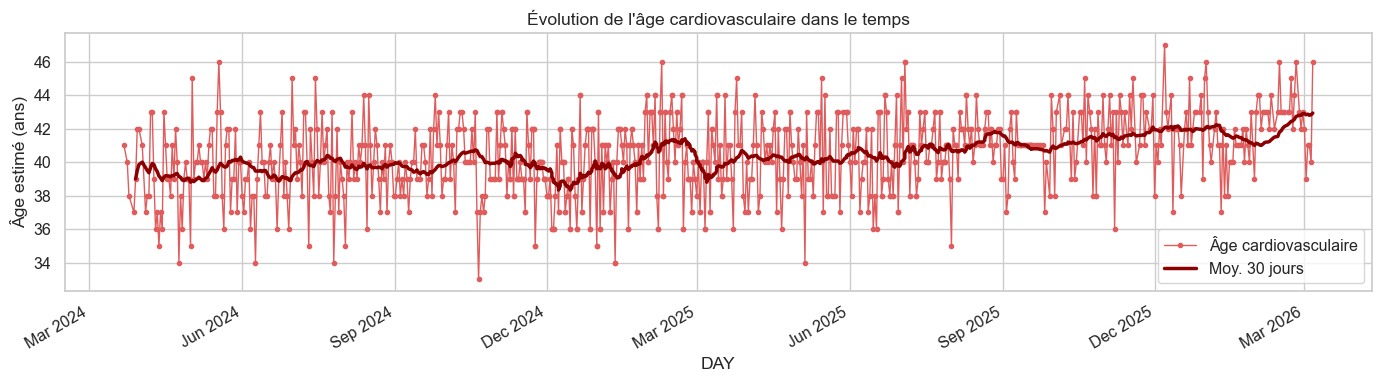

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

vasc = df['VASCULAR_AGE'].dropna()
vasc.plot(ax=ax, marker='o', ms=3, lw=1, color='#e05c5c', label='Âge cardiovasculaire')
vasc.rolling(30, min_periods=5).mean().plot(ax=ax, lw=2.5, color='#8b0000', label='Moy. 30 jours')

ax.set_ylabel('Âge estimé (ans)')
ax.set_title('Évolution de l\'âge cardiovasculaire dans le temps')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4 · Matrice de corrélation

L'analyse porte sur les **jours où `VASCULAR_AGE` est disponible**.
On calcule deux coefficients :
- **Pearson** : corrélation linéaire (sensible aux outliers)
- **Spearman** : corrélation de rang (plus robuste aux distributions asymétriques)

La heatmap affiche les variables les plus corrélées à `VASCULAR_AGE` (|r| trié).

In [7]:
# Colonnes numériques utiles (on exclut WEEKDAY, purement calendaire)
EXCL = {'WEEKDAY'}
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCL]

# Sous-DataFrame : jours où VASCULAR_AGE est disponible
df_cv = df.loc[df['VASCULAR_AGE'].notna(), num_cols].copy()
print(f'Base de corrélation : {len(df_cv)} observations × {len(num_cols)} variables')

corr_p = df_cv.corr(method='pearson')
corr_s = df_cv.corr(method='spearman')

# Top variables corrélées à VASCULAR_AGE (par valeur absolue)
top_abs = (
    corr_p['VASCULAR_AGE']
    .drop('VASCULAR_AGE')
    .dropna()
    .abs()
    .sort_values(ascending=False)
)
TOP_N   = 18
top_vars = top_abs.head(TOP_N).index.tolist() + ['VASCULAR_AGE']
print(f'Top {TOP_N} corrélateurs retenus pour la heatmap.')

Base de corrélation : 875 observations × 29 variables
Top 18 corrélateurs retenus pour la heatmap.


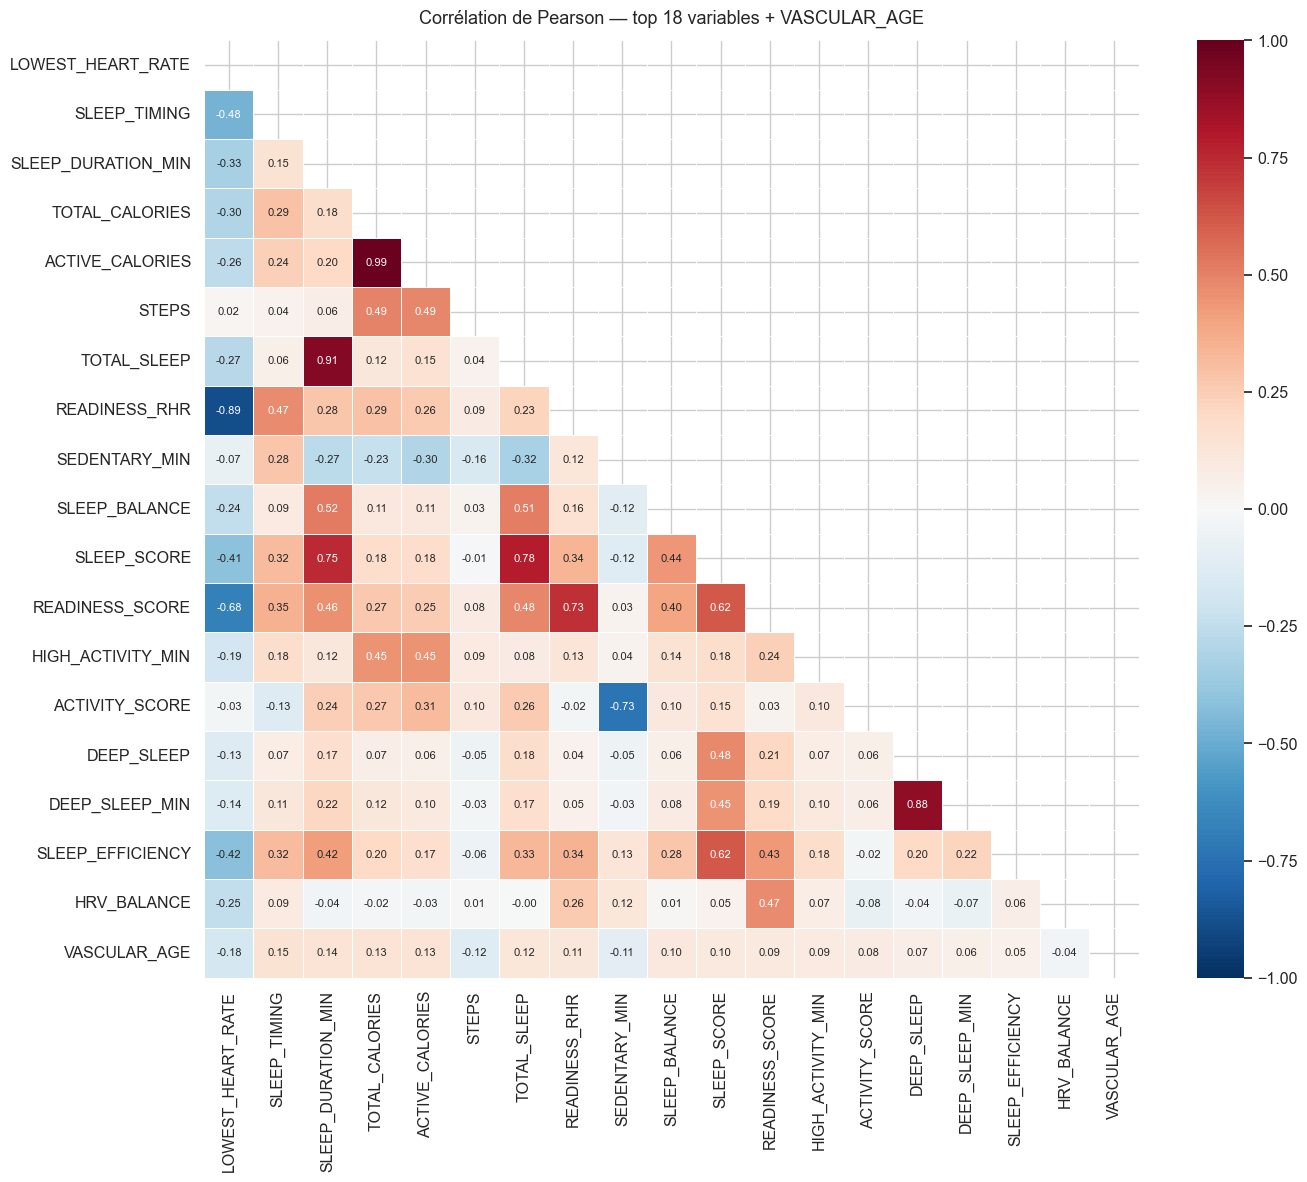

In [8]:
sub_p = corr_p.loc[top_vars, top_vars]
mask  = np.triu(np.ones_like(sub_p, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sub_p, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 8},
)
ax.set_title(f'Corrélation de Pearson — top {TOP_N} variables + VASCULAR_AGE', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

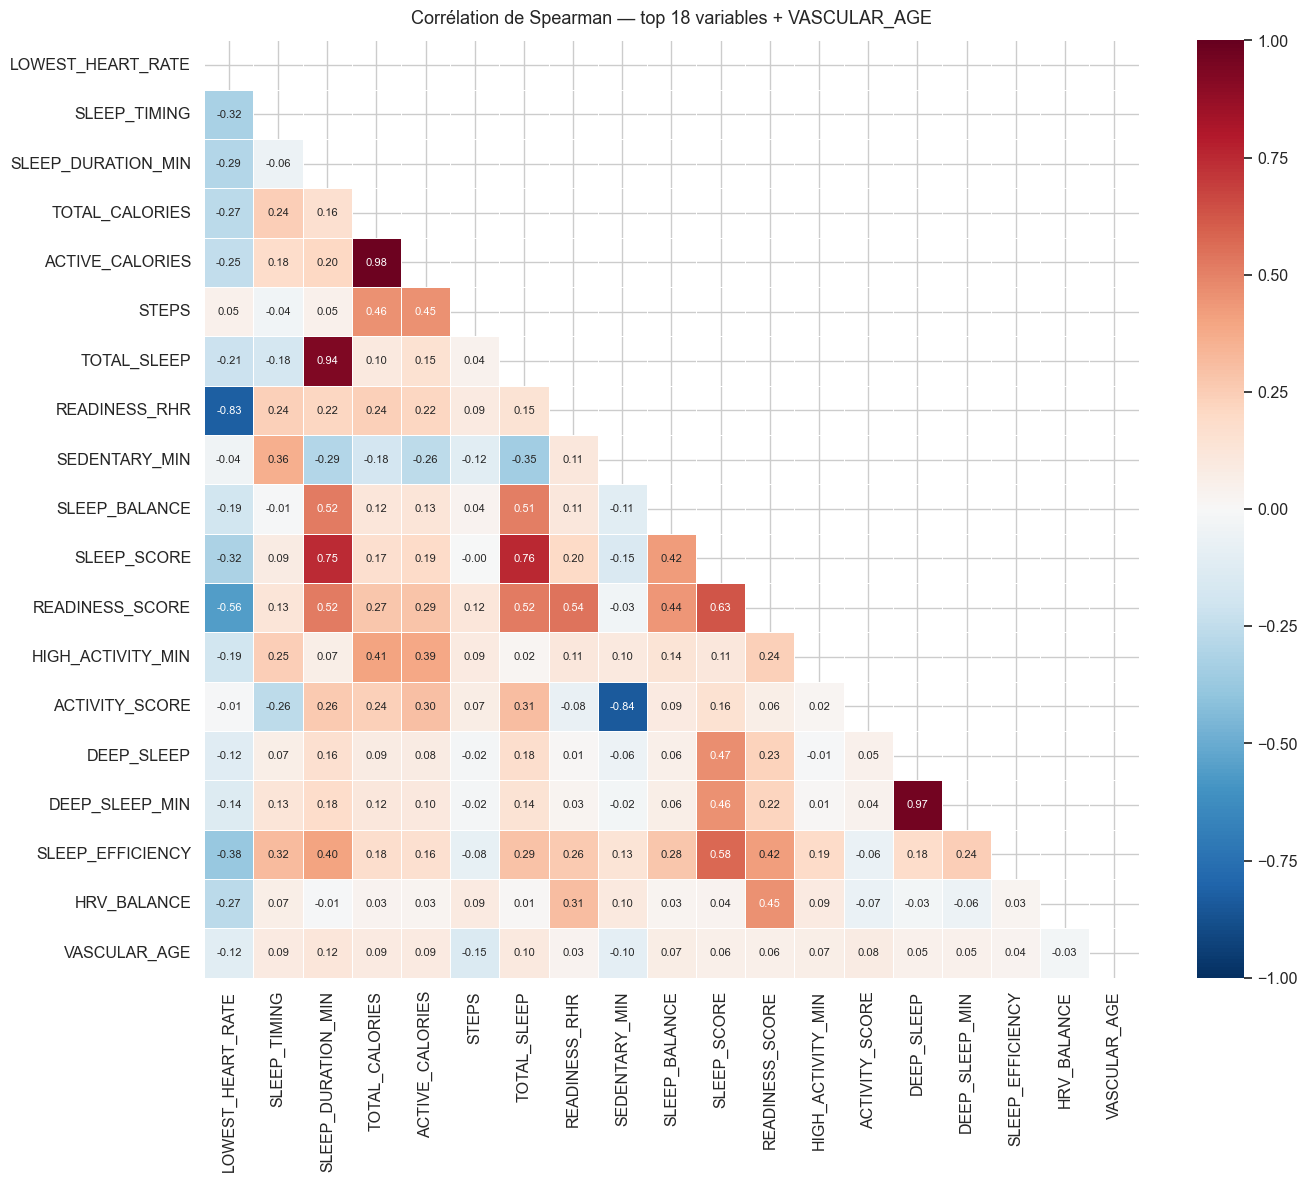

In [9]:
sub_s = corr_s.loc[top_vars, top_vars]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sub_s, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 8},
)
ax.set_title(f'Corrélation de Spearman — top {TOP_N} variables + VASCULAR_AGE', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

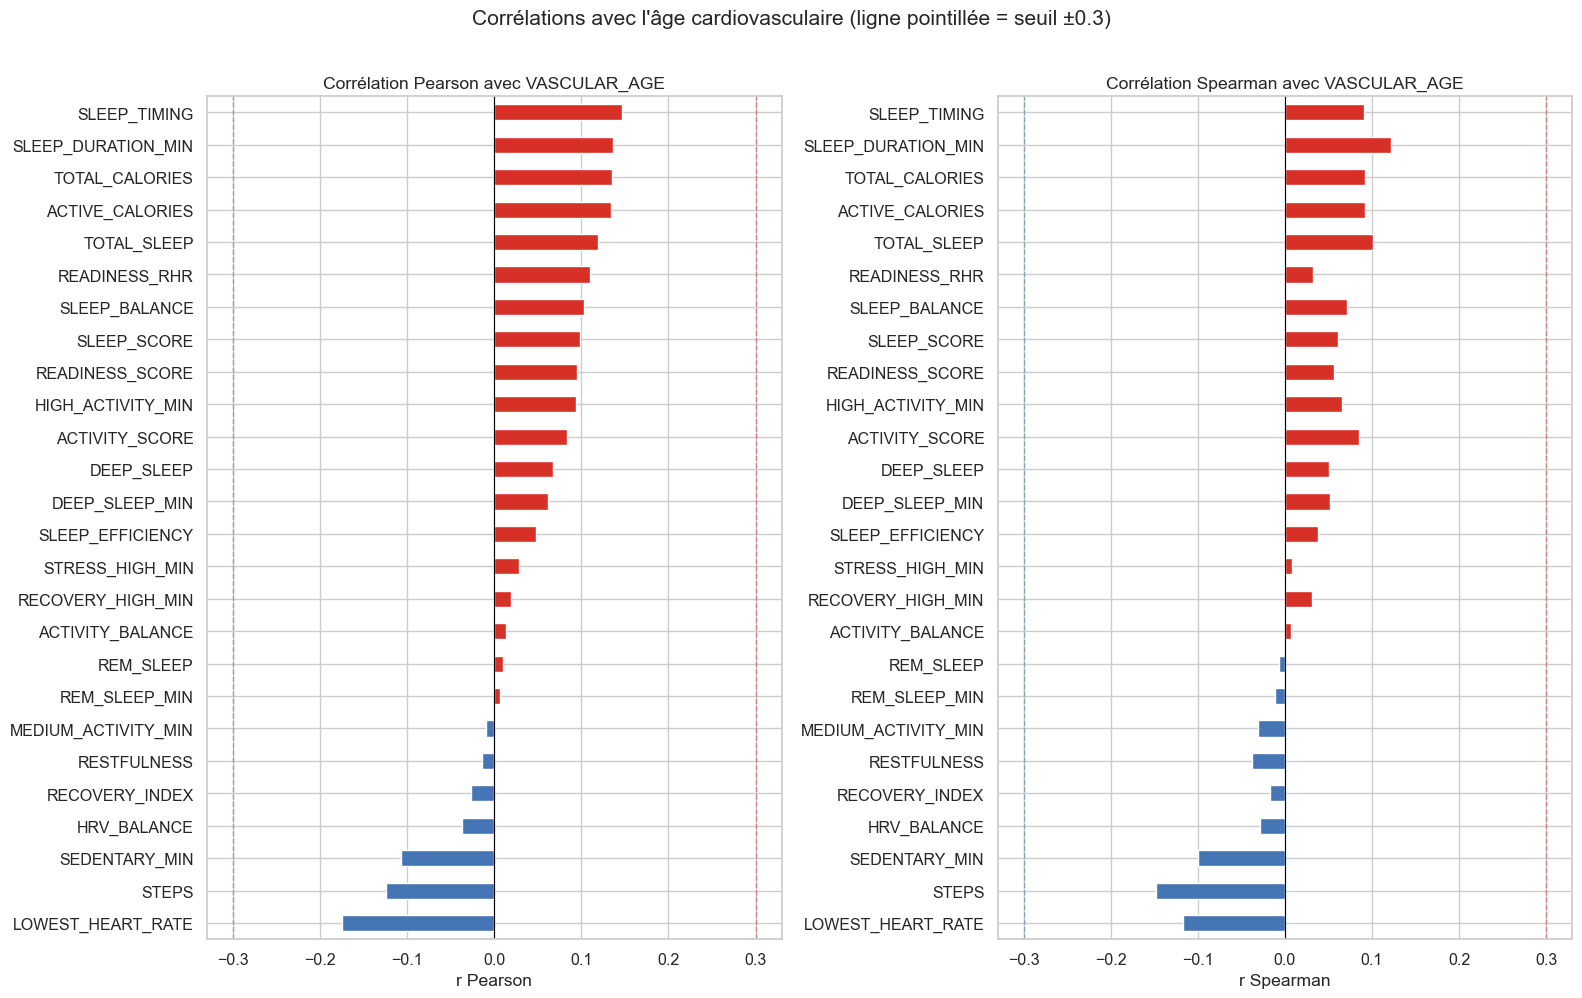

In [10]:
# Toutes les variables, triées par corrélation Pearson avec VASCULAR_AGE
cv_corr_p = corr_p['VASCULAR_AGE'].drop('VASCULAR_AGE').dropna().sort_values()
cv_corr_s = corr_s['VASCULAR_AGE'].drop('VASCULAR_AGE').dropna()

colors = ['#d73027' if v > 0 else '#4575b4' for v in cv_corr_p.values]

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(cv_corr_p) * 0.38)))

for ax, corr, title in zip(
    axes,
    [cv_corr_p, cv_corr_s.reindex(cv_corr_p.index)],
    ['Pearson', 'Spearman'],
):
    col = ['#d73027' if v > 0 else '#4575b4' for v in corr.values]
    corr.plot(kind='barh', ax=ax, color=col)
    ax.axvline(0,    color='black',   lw=0.8)
    ax.axvline( 0.3, color='#d73027', lw=1, linestyle='--', alpha=0.5)
    ax.axvline(-0.3, color='#4575b4', lw=1, linestyle='--', alpha=0.5)
    ax.set_xlabel(f'r {title}')
    ax.set_title(f'Corrélation {title} avec VASCULAR_AGE')

plt.suptitle('Corrélations avec l\'âge cardiovasculaire (ligne pointillée = seuil ±0.3)', y=1.01)
plt.tight_layout()
plt.show()

---
## 5 · Scatter plots — Top corrélateurs

Pour chaque variable parmi les 6 plus corrélées à `VASCULAR_AGE` (en valeur absolue),
un nuage de points avec droite de régression et coefficient r.

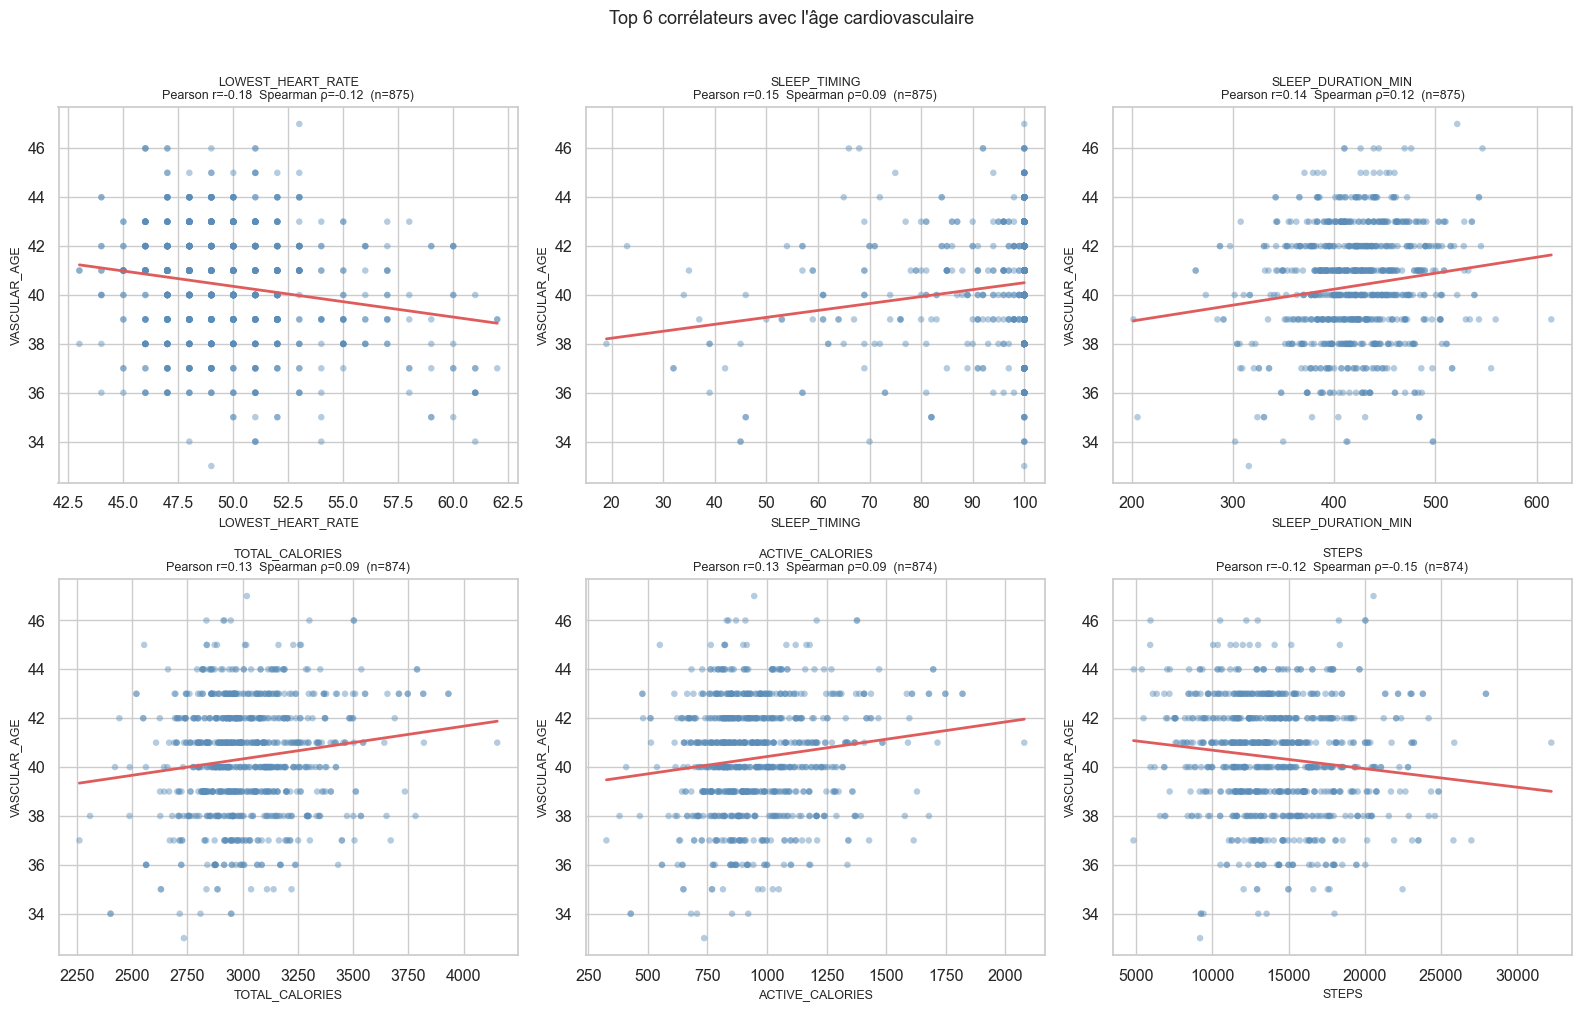

In [11]:
top6 = top_abs.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    sub = df_cv[['VASCULAR_AGE', col]].dropna()
    if len(sub) < 5:
        axes[i].set_visible(False)
        continue

    r, p = stats.pearsonr(sub['VASCULAR_AGE'], sub[col])
    rho, _ = stats.spearmanr(sub['VASCULAR_AGE'], sub[col])

    axes[i].scatter(sub[col], sub['VASCULAR_AGE'],
                    alpha=0.45, s=22, color='#5b8db8', edgecolors='none')

    # Droite de régression
    m, b = np.polyfit(sub[col], sub['VASCULAR_AGE'], 1)
    x_line = np.linspace(sub[col].min(), sub[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='#e05c5c', lw=2)

    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('VASCULAR_AGE', fontsize=9)
    axes[i].set_title(f'{col}\nPearson r={r:.2f}  Spearman ρ={rho:.2f}  (n={len(sub)})', fontsize=9)

plt.suptitle('Top 6 corrélateurs avec l\'âge cardiovasculaire', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 · Analyse par moyennes glissantes (7j / 14j)

Les effets sur la santé cardiovasculaire ne sont pas instantanés — ils reflètent souvent
des **habitudes accumulées**. On calcule les corrélations des moyennes glissantes
sur 7 et 14 jours avec `VASCULAR_AGE`.

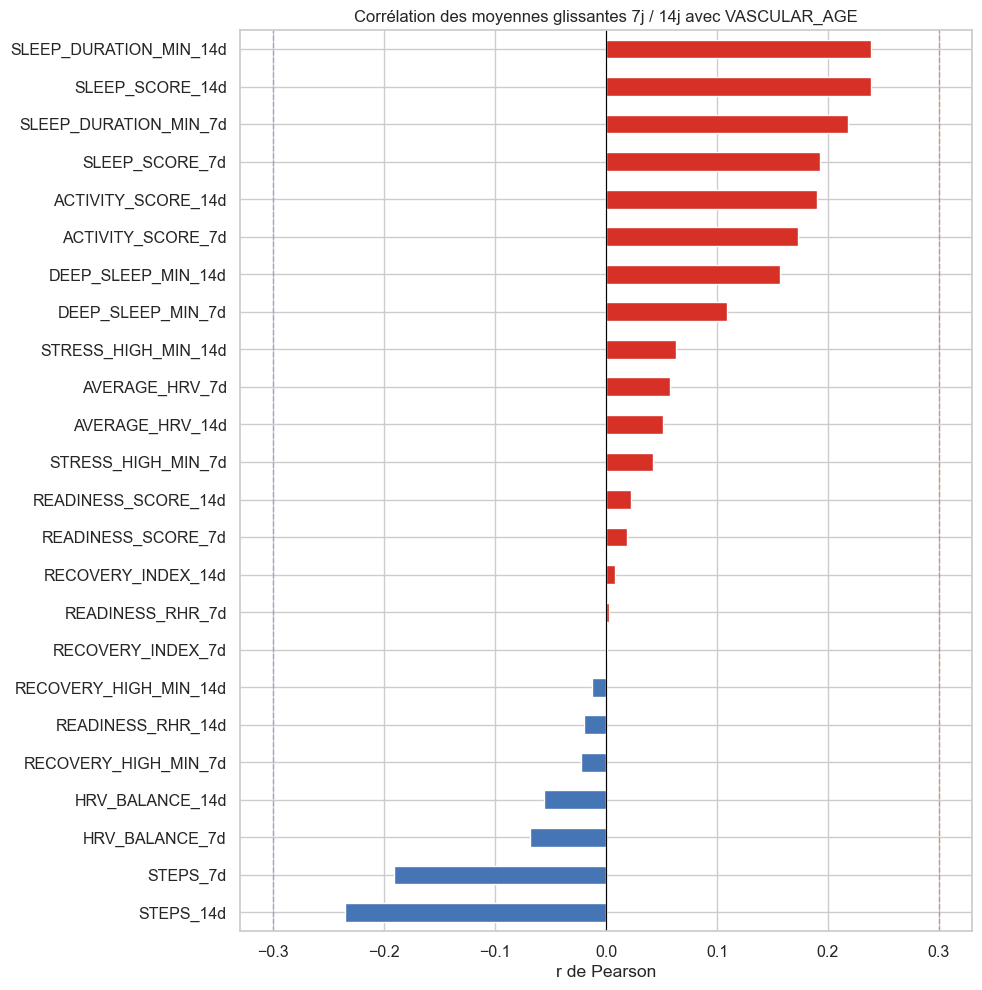

In [12]:
ROLL_VARS = [
    'SLEEP_SCORE', 'ACTIVITY_SCORE', 'READINESS_SCORE',
    'AVERAGE_HRV', 'STEPS', 'STRESS_HIGH_MIN', 'RECOVERY_HIGH_MIN',
    'HRV_BALANCE', 'RECOVERY_INDEX', 'READINESS_RHR',
    'SLEEP_DURATION_MIN', 'DEEP_SLEEP_MIN',
]
ROLL_VARS = [v for v in ROLL_VARS if v in df.columns]

df_roll = df[ROLL_VARS + ['VASCULAR_AGE']].copy()
for var in ROLL_VARS:
    df_roll[f'{var}_7d']  = df_roll[var].rolling(7,  min_periods=4).mean()
    df_roll[f'{var}_14d'] = df_roll[var].rolling(14, min_periods=7).mean()

df_roll_cv = df_roll.loc[df['VASCULAR_AGE'].notna()].copy()

roll_cols = [f'{v}_7d' for v in ROLL_VARS] + [f'{v}_14d' for v in ROLL_VARS]
roll_corr = {}
for col in roll_cols:
    sub = df_roll_cv[['VASCULAR_AGE', col]].dropna()
    roll_corr[col] = stats.pearsonr(sub['VASCULAR_AGE'], sub[col])[0] if len(sub) > 5 else np.nan

roll_s = pd.Series(roll_corr).sort_values()
colors = ['#4575b4' if v < 0 else '#d73027' for v in roll_s.values]

fig, ax = plt.subplots(figsize=(10, max(5, len(roll_s) * 0.42)))
roll_s.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( 0.3, color='#d73027', lw=1, linestyle='--', alpha=0.4)
ax.axvline(-0.3, color='#4575b4', lw=1, linestyle='--', alpha=0.4)
ax.set_xlabel('r de Pearson')
ax.set_title('Corrélation des moyennes glissantes 7j / 14j avec VASCULAR_AGE', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7 · Analyse des décalages temporels (lag)

On teste si la valeur d'une variable **il y a N jours** est un meilleur
prédicteur de `VASCULAR_AGE` qu'au même jour.

Une courbe qui monte avec le lag signifie que les effets passés comptent
plus que la valeur instantanée.

In [13]:
LAG_VARS = [
    'SLEEP_SCORE', 'ACTIVITY_SCORE', 'READINESS_SCORE',
    'AVERAGE_HRV', 'STEPS', 'STRESS_HIGH_MIN',
]
LAG_VARS = [v for v in LAG_VARS if v in df.columns]
LAGS     = [0, 1, 3, 7, 14, 21, 30]

lag_results = {var: {} for var in LAG_VARS}
for var in LAG_VARS:
    for lag in LAGS:
        shifted  = df[var].shift(lag)
        combined = pd.concat([df['VASCULAR_AGE'], shifted], axis=1).dropna()
        combined.columns = ['VASCULAR_AGE', var]
        if len(combined) > 10:
            r, _ = stats.pearsonr(combined['VASCULAR_AGE'], combined[var])
            lag_results[var][lag] = r
        else:
            lag_results[var][lag] = np.nan

df_lag = pd.DataFrame(lag_results, index=LAGS)
df_lag.index.name = 'Lag (jours)'

fig, ax = plt.subplots(figsize=(12, 5))
for col in df_lag.columns:
    ax.plot(df_lag.index, df_lag[col], marker='o', label=col, lw=1.8)

ax.axhline(0,  color='black', lw=0.8)
ax.axvline(0,  color='gray',  lw=0.8, linestyle='--')
ax.set_xlabel('Décalage (jours en arrière)')
ax.set_ylabel('r de Pearson avec VASCULAR_AGE')
ax.set_title('Analyse des décalages temporels — impact différé sur l\'âge cardiovasculaire', fontsize=12)
ax.set_xticks(LAGS)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

print('\nTable des corrélations par lag :')
print(df_lag.round(3))

TypeError: unsupported operand type(s) for +: 'float' and 'decimal.Decimal'

---
## 8 · Séries temporelles

Vue d'ensemble de l'évolution des principales métriques dans le temps,
avec superposition de l'âge cardiovasculaire pour visualiser les tendances communes.

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# ── Panel 1 : Âge cardiovasculaire ──────────────────────────────────────────
ax = axes[0]
df['VASCULAR_AGE'].dropna().plot(ax=ax, marker='o', ms=3, lw=1, color='#e05c5c',
                                  label='Âge cardiovasculaire')
df['VASCULAR_AGE'].dropna().rolling(30).mean().plot(ax=ax, lw=2.5, color='#8b0000',
                                                      label='Moy. 30j')
ax.set_ylabel('Âge (ans)')
ax.set_title('Âge cardiovasculaire estimé')
ax.legend(fontsize=8)

# ── Panel 2 : Scores Oura ────────────────────────────────────────────────────
ax = axes[1]
palette = {'READINESS_SCORE': '#4575b4', 'SLEEP_SCORE': '#74add1', 'ACTIVITY_SCORE': '#f46d43'}
for col, color in palette.items():
    if col in df.columns:
        df[col].rolling(7).mean().plot(ax=ax, lw=1.5, color=color,
                                        label=col.replace('_SCORE', '').capitalize() + ' (moy. 7j)')
ax.set_ylabel('Score (0–100)')
ax.set_title('Scores Oura (moyenne 7 jours glissants)')
ax.legend(fontsize=8)

# ── Panel 3 : HRV ───────────────────────────────────────────────────────────
ax = axes[2]
if 'AVERAGE_HRV' in df.columns:
    df['AVERAGE_HRV'].rolling(7).mean().plot(ax=ax, lw=1.5, color='#9e9ac8',
                                              label='HRV (moy. 7j)')
if 'HRV_BALANCE' in df.columns:
    df['HRV_BALANCE'].rolling(7).mean().plot(ax=ax, lw=1.5, color='#6a51a3',
                                              linestyle='--', label='HRV Balance (moy. 7j)')
ax.set_ylabel('HRV (ms) / score')
ax.set_title('HRV nocturne moyen et équilibre HRV')
ax.legend(fontsize=8)

# ── Panel 4 : Pas + Stress ──────────────────────────────────────────────────
ax4 = axes[3]
if 'STEPS' in df.columns:
    df['STEPS'].rolling(7).mean().plot(ax=ax4, lw=1.5, color='#74c476',
                                        label='Pas (moy. 7j)')
ax4.set_ylabel('Pas')
ax5 = ax4.twinx()
if 'STRESS_HIGH_MIN' in df.columns:
    df['STRESS_HIGH_MIN'].rolling(7).mean().plot(ax=ax5, lw=1.5, color='#fd8d3c',
                                                  linestyle='--', label='Stress élevé (moy. 7j)')
ax5.set_ylabel('Minutes de stress élevé')
ax4.set_title('Activité (pas) et stress élevé')

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax5.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')

plt.suptitle('Vue d\'ensemble — Évolution temporelle des métriques clés', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 9 · Interprétation via l'API Claude *(optionnel)*

Cette section envoie un résumé des résultats statistiques à Claude (API Anthropic)
pour obtenir une interprétation en langage naturel.

**Pré-requis :** ajouter `ANTHROPIC_API_KEY=sk-ant-...` dans le fichier `.env`
et décommenter le code ci-dessous.

Installer la librairie si nécessaire : `pip install anthropic`

In [ ]:
# ── Décommentez ce bloc pour activer l'interprétation Claude ─────────────────

# import anthropic
#
# ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', '')
# if not ANTHROPIC_API_KEY:
#     print('⚠️  ANTHROPIC_API_KEY absent du .env — section ignorée')
# else:
#     # Résumé compact à envoyer à l'API
#     top10_signed = corr_p['VASCULAR_AGE'].drop('VASCULAR_AGE').dropna()
#     top10_signed = top10_signed.reindex(top10_signed.abs().sort_values(ascending=False).head(10).index)
#
#     lag_summary = df_lag.round(3).to_string()
#     roll_summary = roll_s.round(3).to_string()
#     stats_cv = df['VASCULAR_AGE'].describe().round(2).to_dict()
#
#     prompt = f"""
# I have {len(df_cv)} days of personal health data from an Oura Ring.
# The target variable is VASCULAR_AGE (estimated cardiovascular age from HRV
# and resting heart rate). My actual biological age is [YOUR AGE].
#
# Key statistics for VASCULAR_AGE:
# {stats_cv}
#
# Top 10 Pearson correlations with VASCULAR_AGE (sorted by |r|):
# {top10_signed.round(3).to_string()}
#
# Rolling-average correlations (7-day and 14-day) with VASCULAR_AGE:
# {roll_summary}
#
# Lag correlations (does past behaviour predict VASCULAR_AGE better?):
# {lag_summary}
#
# Please interpret these results in plain language:
# 1. Which variables most strongly predict cardiovascular age?
# 2. Are there any surprising or counter-intuitive findings?
# 3. What concrete behavioural recommendations do these patterns suggest?
# 4. What are the main statistical limitations of this analysis (n, causality, etc.)?
# """
#
#     client  = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
#     message = client.messages.create(
#         model='claude-opus-4-5',
#         max_tokens=1500,
#         messages=[{'role': 'user', 'content': prompt}],
#     )
#     print(message.content[0].text)

print('Section Claude API : décommentez le bloc ci-dessus après avoir ajouté ANTHROPIC_API_KEY dans .env')